# Importing dataset

In [1]:
import pandas as pd
df = pd.read_csv("../data/subscribers.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Each row represents a customer, each column contains customer’s attributes described on the column Metadata.

The raw data contains 7043 rows (customers) and 21 columns (features).

The “Churn” column is our target.

In [2]:
df.shape

(7043, 21)

## Column dictionary
* gender: Whether the customer is a male or a female
* SeniorCitizen: Whether the customer is a senior citizen or not (1, 0)
* Partner: Whether the customer has a partner or not (Yes or No)
* Dependents: Whether the customer has dependents or not (Yes, No)
* Tenure: Number of months the customer has stayed with the company
* PhoneService: Whether the customer has a phone service or not (Yes, No)
* MultipleLines: Whether the customer has multiple lines or not (Yes, No, No phone service)
* InternetService: Customer’s internet service provider (DSL, Fiber optic, No)
* OnlineSecurity: Whether the customer has online security or not (Yes, No, No internet service)
* OnlineBackup: Whether the customer has online backup or not (Yes, No, No internet service)
* DeviceProtection: Whether the customer has device protection or not (Yes, No, No internet service)
* TechSupport: Whether the customer has tech support or not (Yes, No, No internet service)
* StreamingTV: Whether the customer has streaming TV or not (Yes, No, No internet service)
* StreamingMovies: Whether the customer has streaming movies or not (Yes, No, No internet service)
* Contract: The contract term of the customer (Month-to-month, One year, Two year)
* PaperlessBilling: Whether the customer has paperless billing or not (Yes, No)
* PaymentMethod: The customer’s payment method (Electronic check, Mailed check, Bank transfer (automatic), Credit card (automatic))
* MonthlyCharges: The amount charged to the customer monthly
* TotalCharges: The total amount charged to the customer
* Churn: Whether the customer churned or not (Yes or No)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

TotalCharges feature seems to have the wrong datatype, needs fix.

In [4]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
print(df['TotalCharges'].value_counts())

TotalCharges
20.2      11
          11
19.75      9
19.9       8
20.05      8
          ..
1990.5     1
7362.9     1
346.45     1
306.6      1
6844.5     1
Name: count, Length: 6531, dtype: int64


There are 11 'empty' rows in TotalCharges column that weren't spotted by NaN quantification. Could make an inputition step to calculate TotalCharges based on Tenure and Monthly payed.

In [6]:
df[df['TotalCharges'] == ' '][['tenure', 'MonthlyCharges', 'TotalCharges']]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,
753,0,20.25,
936,0,80.85,
1082,0,25.75,
1340,0,56.05,
3331,0,19.85,
3826,0,25.35,
4380,0,20.00,
5218,0,19.70,
6670,0,73.35,


tenure = 0 means these are brand new customers, they haven't completed a billing cycle yet, so TotalCharges being empty is correct. Let's entirely drop this customers from churn analysis and type cast TotalCharges into float.

In [7]:
# Dropping empty TotalCharges rows
df = df[df["TotalCharges"] != ' ']
print(df.shape)

# Type casting TotalCharges feature to float
df["TotalCharges"] = df["TotalCharges"].astype(float)

# Chechking if changes worked
df.info()

(7032, 21)
<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  

## Balance Analysis

In [16]:
balance_analysis = pd.DataFrame({
    'Count': df['Churn'].value_counts(),
    'Percentage': df["Churn"].value_counts(normalize=True) * 100
})
print(balance_analysis)

       Count  Percentage
Churn                   
No      5163   73.421502
Yes     1869   26.578498


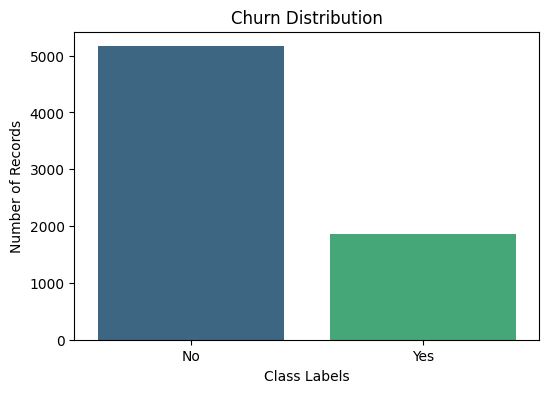

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=df["Churn"], hue=df["Churn"], palette='viridis', legend=False)
plt.title('Churn Distribution')
plt.xlabel('Class Labels')
plt.ylabel('Number of Records')
plt.show()

Mild imbalance detected, prediction analysis will need some imbalance handling techniques to avoid biases and false negatives.

Need to be careful about accuracy metric, could be fooling us to beliving the model is good.

## Univariate analysis of numerical features.

In [31]:
# Type-casting SeniorCitizen column first
df["SeniorCitizen"] = df["SeniorCitizen"].astype('category')

# 1. Get all numerical columns
num_cols = df.select_dtypes(include=['number']).columns.tolist()

# 2. Get all categorical columns
cat_cols = df.select_dtypes(include=['object', 'category', 'str']).columns.tolist()

# Let's see what we got
print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [32]:
df[num_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


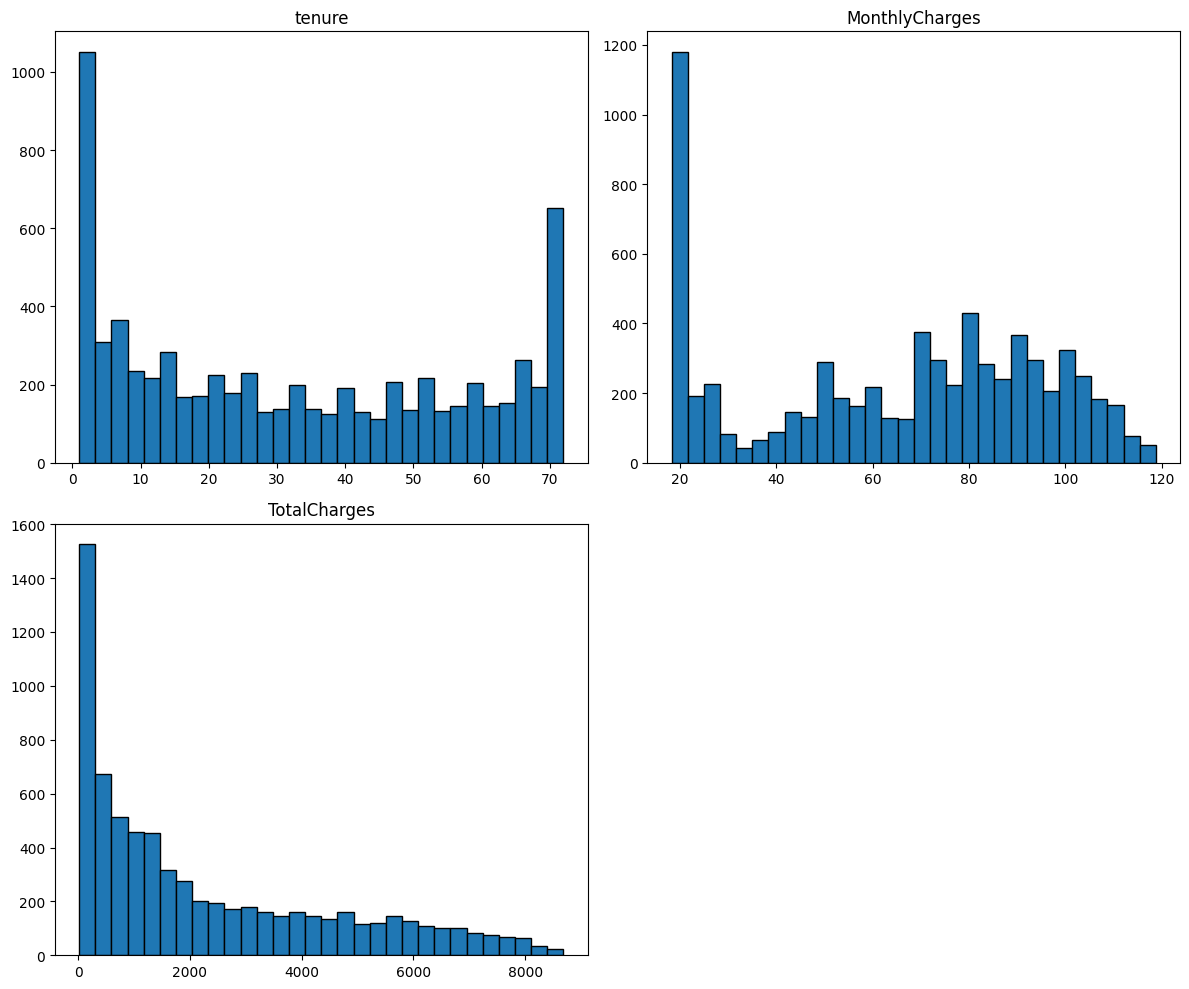

In [33]:
df[num_cols].hist(figsize=(12, 10), bins=30, edgecolor='black', grid=False)
plt.tight_layout()
plt.show();

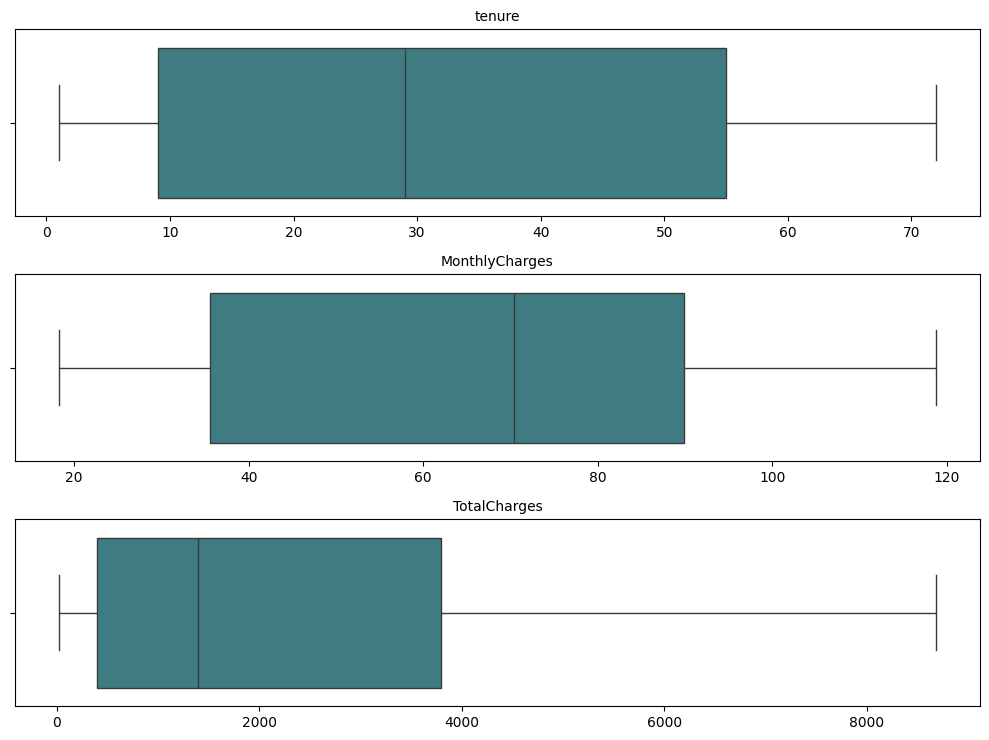

In [34]:
# Create subplots dynamically based on the number of numeric columns
fig, axes = plt.subplots(nrows=len(num_cols), ncols=1, figsize=(10, len(num_cols) * 2.5))

if len(num_cols) == 1:
    axes = [axes]

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i], palette='crest', hue=axes[i], legend=False)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show();

In [35]:
# Calculate skewness for numerical features
df[num_cols].skew()

tenure            0.237731
MonthlyCharges   -0.222103
TotalCharges      0.961642
dtype: float64

How to interpret the skewness score:
* Close to 0: Fairly symmetrical (Normal distribution).

* Greater than 1: Highly positively skewed (Right-skewed). Your data has a long tail of high values (like Income or House Prices). You might need a Log Transformation here before feeding this to a linear model.

* Less than -1: Highly negatively skewed (Left-skewed). Your data has a long tail of low values (like Age of retirement).

* **Tenure:** Bimodal customer base: large spike of new customers (p25=9mo) and a retained cohort near the max (72mo)
* **MonthlyCharges:** Tail of low values, meaning low price plans are common; Wide spread suggests multiple pricing tiers
* **TotalCharges:** Highly positively skewed with a long tail of high values driven by long-tenure customers accumulating charges